In [1]:
import numpy as np
import pandas as pd 


In [2]:
df = pd.read_csv('../data/Admission_Predict.csv')


In [3]:
# Getting to know about the data
print(f"Shape of the dataset : {df.shape}")
df.head()

Shape of the dataset : (500, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
# Checking the datatypes 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [5]:
# checking Is there any duplicate values in data set
df.duplicated().sum()

0

In [6]:
# Number of customer exited from bank 1-->exit
df['University Rating'].value_counts()

University Rating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64

In [7]:
df['Research'].value_counts()

Research
1    280
0    220
Name: count, dtype: int64

In [8]:
df.drop(columns=['Serial No.'], inplace=True)

In [9]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [10]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=34)

print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of y_train : {y_train.shape}")

Shape of X_train : (400, 7)
Shape of y_train : (400,)


In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()    

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [13]:
X_test_scaled

array([[0.5       , 0.46428571, 0.5       , 0.625     , 0.5       ,
        0.49442379, 0.        ],
       [0.43478261, 0.64285714, 0.5       , 0.75      , 0.75      ,
        0.58364312, 0.        ],
       [0.91304348, 0.92857143, 1.        , 0.875     , 0.75      ,
        0.72862454, 1.        ],
       [0.47826087, 0.64285714, 0.5       , 0.75      , 0.875     ,
        0.57620818, 1.        ],
       [0.34782609, 0.64285714, 0.        , 0.125     , 0.75      ,
        0.        , 1.        ],
       [0.56521739, 0.42857143, 0.5       , 0.625     , 0.875     ,
        0.41263941, 1.        ],
       [0.15217391, 0.35714286, 0.5       , 0.375     , 0.25      ,
        0.33457249, 1.        ],
       [0.54347826, 0.71428571, 0.5       , 0.375     , 0.25      ,
        0.55018587, 1.        ],
       [0.43478261, 0.35714286, 0.75      , 0.375     , 0.25      ,
        0.24163569, 1.        ],
       [0.7826087 , 0.85714286, 0.75      , 0.75      , 0.625     ,
        0.74349442, 1. 

In [14]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

model = Sequential()

model.add(Dense(7,activation='relu', input_dim=7))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='linear'))




/Users/arbazkhan/kael/kael_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147 (588.00 B)

 Trainable params: 147 (588.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='mean_squared_error', optimizer='Adam')

In [17]:
hist = model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0158 - val_loss: 1.7790
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6215 - val_loss: 1.4432
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3285 - val_loss: 1.1862
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0959 - val_loss: 0.9840
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9050 - val_loss: 0.8131
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7374 - val_loss: 0.6583
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5870 - val_loss: 0.5133
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4461 - val_loss: 0.3842
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3238 - val_loss: 0.2716
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2215 - val_loss: 0.1781
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1406 - val_loss: 0.1091
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0853 - val_lo

In [18]:
y_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [19]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)


0.7454473495568068

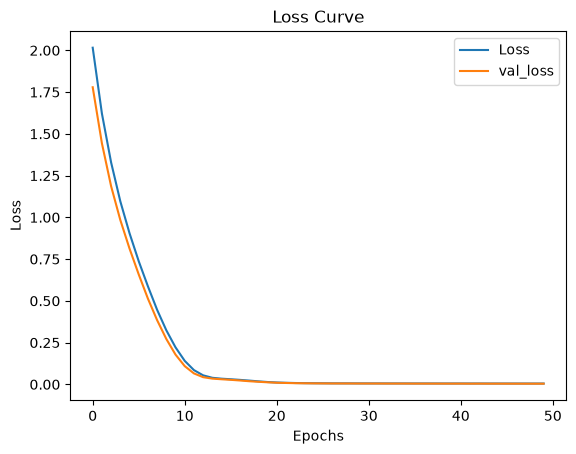

In [20]:
# =======================================
# MODULE 4: MODEL SCORE VISUALIZATION 
# =======================================

import matplotlib.pyplot as plt

# Training Loss vs  Validation Loss
plt.plot(hist.history['loss'], label='Loss')
plt.plot(hist.history['val_loss'], label ='val_loss')
plt.title("Loss Curve")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()